In [1]:
# Import libraries
import pandas as pd
import numpy as np
import random as rd
import pprint as pp
import matplotlib.pyplot as plt

from sklearn.utils import resample
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import root_mean_squared_error

In [2]:
# Import file
DF = pd.read_excel(r'C:/Users/Pongo/Downloads/Data Tensorflow TA.xlsx')

In [3]:
# Management functions
def data_upsample(ORIGINAL_FEATURES, ORIGINAL_LABEL):
    ORIGINAL_DATA = np.column_stack([ORIGINAL_FEATURES, ORIGINAL_LABEL])
    while True:
        POP = [[], []]
        POP[0], POP[1] = np.unique(ORIGINAL_DATA[:, -1], return_counts = True)
        pop_maj = POP[0][np.argmax(POP[1])]
        pop_min = POP[0][np.argmin(POP[1])]
        if len(ORIGINAL_DATA[ORIGINAL_DATA[:, -1] == pop_min])*10 >= len(ORIGINAL_DATA[ORIGINAL_DATA[:, -1] == pop_maj]):
            return ORIGINAL_DATA
        
        DATA_ELSE = ORIGINAL_DATA[ORIGINAL_DATA[:, -1] != pop_min]
        DATA_MIN = ORIGINAL_DATA[ORIGINAL_DATA[:, -1] == pop_min]
        FEATURES_UPSAMPLE, LABEL_UPSAMPLE = resample(DATA_MIN[:, :-1], DATA_MIN[:, -1], replace = True, n_samples = len(ORIGINAL_DATA[ORIGINAL_DATA[:, -1] == pop_maj]), random_state = 0)
        NEW_FEATURES = np.concatenate((FEATURES_UPSAMPLE, DATA_ELSE[:, :-1]))
        NEW_LABEL= np.concatenate((LABEL_UPSAMPLE, DATA_ELSE[:, -1]))
        ORIGINAL_DATA = np.column_stack([NEW_FEATURES, NEW_LABEL])

def look_ahead(INPUT_DATA, n_lookahead):
    INPUT_DATA_FEATURES = INPUT_DATA[:-n_lookahead, :-1]
    INPUT_DATA_LABEL = INPUT_DATA[n_lookahead:, -1]
    return np.column_stack([INPUT_DATA_FEATURES, INPUT_DATA_LABEL])

def list_sort(LIST):
  SORTED_LIST = [[], []]
  while len(LIST[1]) > 0:
    SORTED_LIST[0].append(LIST[0][LIST[1].index(min(LIST[1]))])
    SORTED_LIST[1].append(LIST[1][LIST[1].index(min(LIST[1]))])
    LIST[0].pop(LIST[1].index(min(LIST[1])))
    LIST[1].pop(LIST[1].index(min(LIST[1])))
  return SORTED_LIST

def class_accuracy(RESULT, ACTUAL, title = "Accuracy :"):
    ACCURACY_TABLE = np.zeros((len(np.unique(RESULT)), len(np.unique(ACTUAL))))
    for j in range(len(RESULT)):
        ACCURACY_TABLE[int(RESULT[j]), int(ACTUAL[j])] += 1
    ACCURACY_TABLE = ACCURACY_TABLE/len(RESULT)
    ACCURACY_TABLE = pd.DataFrame(data = ACCURACY_TABLE, index = ["Result %i" % int(n) for n in np.unique(RESULT)], columns = ["Actual %i" % int(n) for n in np.unique(ACTUAL)])
    print(title)
    print(ACCURACY_TABLE)
    print("RMSE : %f" % root_mean_squared_error(ACTUAL, RESULT))
    print()

# Linear regression modelling functions
def linreg_model(FEATURES_MODEL, INTERCEPT_MODEL, slope_model):
    LABEL_MODEL = np.zeros(FEATURES_MODEL.shape[0])
    for i in range(FEATURES_MODEL.shape[0]):
        LABEL_MODEL[i] = np.dot(INTERCEPT_MODEL, FEATURES_MODEL[i]) + slope_model
    return LABEL_MODEL

def linreg_mse(FEATURES_MSE, CURRENT_LABEL, INTERCEPT_MSE, slope_mse):
    NEW_LABEL = linreg_model(FEATURES_MSE, INTERCEPT_MSE, slope_mse)
    return np.sum((NEW_LABEL - CURRENT_LABEL)**2)/(2*INTERCEPT_MSE.shape[0])

def linreg_iter(FEATURES_ITER, LABEL_ITER, INTERCEPT_ITER, slope_iter, slope_calc_status):
    slope_delta = 0
    INTERCEPT_DELTA = np.zeros(FEATURES_ITER.shape[1])
    for i in range(FEATURES_ITER.shape[0]):
        error = np.dot(INTERCEPT_ITER, FEATURES_ITER[i]) + slope_iter - LABEL_ITER[i]
        INTERCEPT_DELTA += error*FEATURES_ITER[i]
        if slope_calc_status:
            slope_delta += error
    INTERCEPT_DELTA /= FEATURES_ITER.shape[0]
    if slope_calc_status:
        slope_delta /= FEATURES_ITER.shape[0]
    return [slope_delta, INTERCEPT_DELTA]

def linreg_fit(FEATURES_FIT, LABEL_FIT, INTERCEPT = [], slope = 0, slope_calc = True, force_nn = False, fitting_rate = 1E-1, epoch = 1E3, return_plots = False):
    if INTERCEPT == []:
        INTERCEPT = np.ones(shape = (FEATURES_FIT.shape[1]))
    if slope_calc == False and slope != 0:
        slope = 0
    for n in range(int(epoch)):
        [slope_fit, INTERCEPT_FIT] = linreg_iter(FEATURES_FIT, LABEL_FIT, INTERCEPT, slope, slope_calc)
        slope = slope - fitting_rate*slope_fit
        INTERCEPT = INTERCEPT - fitting_rate*INTERCEPT_FIT
        if force_nn:
            INTERCEPT[INTERCEPT < 0] = 0
    if return_plots:
        FEATURE_NAME = DF.iloc[:, :-1].columns.to_list()
        fit_fig = plt.figure(figsize = (4, FEATURES_FIT.shape[1]*3))
        fit_ax = fit_fig.subplots(FEATURES_FIT.shape[1], 1)
        for j in range(FEATURES_FIT.shape[1]):
            fit_ax[j].scatter(FEATURES_FIT[:, j], LABEL_FIT)
            fit_ax[j].plot(FEATURES_FIT[:, j], FEATURES_FIT[:, j]*INTERCEPT[j] + slope)
            fit_ax[j].set_xlabel(FEATURE_NAME[j])
            fit_ax[j].set_ylabel("Label")
            fit_ax[j].legend(["Training values", "Model"])
            fit_ax[j].grid()
        plt.tight_layout()
        plt.show()
        plt.close(fit_fig)
    return [INTERCEPT, slope]

# Random forest modelling functions
def dtree_purity(LABEL_PURITY):
    UNIQUE_LABEL = np.unique(LABEL_PURITY)
    if len(UNIQUE_LABEL) == 1:
        purity_status = True
    else:
        purity_status = False
    return purity_status

def dtree_class(LABEL_CLASS):
    UNIQUE_CLASS = [[], []]
    UNIQUE_CLASS[0], UNIQUE_CLASS[1] = np.unique(LABEL_CLASS, return_counts = True)
    mode_index = UNIQUE_CLASS[1].argmax()
    return UNIQUE_CLASS[0][mode_index]

def dtree_pot(FEATURES_POT, subspace_pot):
    SPLIT_POTENTIAL = {}
    INDEX_POT = [i for i in range(FEATURES_POT.shape[1])]
    if subspace_pot and subspace_pot <= len(DTREE_INFO['IMPORTANCES']):
        INDEX_POT = rd.sample(population = INDEX_POT, k = subspace_pot)
    for i in INDEX_POT:
        FEATURE_VALUES = FEATURES_POT[:, i]
        SPLIT_POTENTIAL[i] = np.unique(FEATURE_VALUES)
    return SPLIT_POTENTIAL

def dtree_split(FEATURES_SPLIT, LABEL_SPLIT, split_index, split_value):
    DATA_SPLIT = np.column_stack([FEATURES_SPLIT, LABEL_SPLIT])
    SPLIT_PARAMS = DATA_SPLIT[:, split_index]
    DATA_LOWER = DATA_SPLIT[SPLIT_PARAMS <= split_value]
    DATA_HIGHER = DATA_SPLIT[SPLIT_PARAMS > split_value]
    return [DATA_LOWER, DATA_HIGHER]

def dtree_entropy(LABEL_ENTROPY):
    UNIQUE_ENTROPY = [[], []]
    UNIQUE_ENTROPY[0], UNIQUE_ENTROPY[1] = np.unique(LABEL_ENTROPY, return_counts = True)
    PROB = UNIQUE_ENTROPY[1]/UNIQUE_ENTROPY[1].sum()
    return sum(PROB*(-np.log2(PROB)))

def dtree_gini(LABEL_ENTROPY):
    UNIQUE_ENTROPY = [[], []]
    UNIQUE_ENTROPY[0], UNIQUE_ENTROPY[1] = np.unique(LABEL_ENTROPY, return_counts = True)
    PROB = UNIQUE_ENTROPY[1]/UNIQUE_ENTROPY[1].sum()
    return 1 - (PROB**2).sum()

def dtree_overall(LABEL_LOWER, LABEL_HIGHER):
    p_lower = len(LABEL_LOWER)/(len(LABEL_LOWER) + len(LABEL_HIGHER))
    p_higher = len(LABEL_HIGHER)/(len(LABEL_LOWER) + len(LABEL_HIGHER))
    return p_lower*dtree_gini(LABEL_LOWER) + p_higher*dtree_gini(LABEL_HIGHER)

def dtree_optimal(FEATURES_OPTIMAL, LABEL_OPTIMAL, SPLIT_VALUES):
    overall = 99
    for i in SPLIT_VALUES:
        for j in SPLIT_VALUES[i]:
            SPLITTED_LABEL = dtree_split(FEATURES_OPTIMAL, LABEL_OPTIMAL, i, j)
            new_overall = dtree_overall(SPLITTED_LABEL[0][:, -1], SPLITTED_LABEL[1][:, -1])
            if new_overall <= overall:
                overall = new_overall
                OPTIMAL_SPLIT = [i, j]
    return OPTIMAL_SPLIT

def dtree_fit(FEATURES_FIT, LABEL_FIT, branch_limit = 1E5, min_samples = 2, n_branch = 0, n_subspace = None):
    if n_branch == 0:
        global DTREE_INFO
        DTREE_INFO = {}
        DTREE_INFO['n_data'] = len(LABEL_FIT)
        DTREE_INFO['IMPORTANCES'] = np.zeros(FEATURES_FIT.shape[1])
        DTREE_INFO['FEATURE_FREQUENCY'] = np.zeros(FEATURES_FIT.shape[1])
    if dtree_purity(LABEL_FIT):
        model_class = dtree_class(LABEL_FIT)
        return [model_class, 'reached_purity']
    elif len(LABEL_FIT) < min_samples:
        model_class = dtree_class(LABEL_FIT)
        return [model_class, 'reached_min_samples']
    elif n_branch >= branch_limit:
        model_class = dtree_class(LABEL_FIT)
        return [model_class, 'reached_branch_limit']
    else:
        n_branch += 1
        MODEL_POT = dtree_pot(FEATURES_FIT, n_subspace)
        OPTIMAL_MODEL = dtree_optimal(FEATURES_FIT, LABEL_FIT, MODEL_POT)
        SPLITTED_DATA = dtree_split(FEATURES_FIT, LABEL_FIT, OPTIMAL_MODEL[0], OPTIMAL_MODEL[1])
        if len(SPLITTED_DATA[0]) == 0 or len(SPLITTED_DATA[1]) == 0:
            model_class = dtree_class(LABEL_FIT)
            return [model_class, 'didnt_find_split']
        branch = "{} <= {}".format(OPTIMAL_MODEL[0], OPTIMAL_MODEL[1])
        SUB_TREE = {branch: []}
        YES_BRANCH = dtree_fit(SPLITTED_DATA[0][:, :-1], SPLITTED_DATA[0][:, -1], branch_limit, min_samples, n_branch, n_subspace)
        NO_BRANCH = dtree_fit(SPLITTED_DATA[1][:, :-1], SPLITTED_DATA[1][:, -1], branch_limit, min_samples, n_branch, n_subspace)
        if YES_BRANCH == NO_BRANCH:
            SUB_TREE = YES_BRANCH
        else:
            SUB_TREE[branch].append(YES_BRANCH)
            SUB_TREE[branch].append(NO_BRANCH)
        gain = dtree_gini(LABEL_FIT)
        gain -= (len(SPLITTED_DATA[0][:, -1])*dtree_gini(SPLITTED_DATA[0][:, -1]) + len(SPLITTED_DATA[1][:, -1])*dtree_gini(SPLITTED_DATA[1][:, -1]))/len(LABEL_FIT)
        DTREE_INFO['IMPORTANCES'][OPTIMAL_MODEL[0]] += (len(LABEL_FIT)/DTREE_INFO['n_data'])*gain
        DTREE_INFO['FEATURE_FREQUENCY'][OPTIMAL_MODEL[0]] += 1
        return SUB_TREE

def dtree_element(FEATURES_ELEMENT, TREE):
    branching = list(TREE.keys())[0]
    BRANCHING_PARAM = branching.split()
    if FEATURES_ELEMENT[int(BRANCHING_PARAM[0])] <= float(BRANCHING_PARAM[2]):
        BRANCH = TREE[branching][0]
    else:
        BRANCH = TREE[branching][1]
    if not isinstance(BRANCH, dict):
        return BRANCH[0]
    else:
        return dtree_element(FEATURES_ELEMENT, BRANCH)

def dtree_model(FEATURES_MODEL, TREE_MODEL):
    LABEL_MODEL = np.zeros(FEATURES_MODEL.shape[0])
    for j in range(FEATURES_MODEL.shape[0]):
        LABEL_MODEL[j] = dtree_element(FEATURES_MODEL[j], TREE_MODEL)
    return LABEL_MODEL

def dtree_benchmark(FEATURES_BENCHMARK, LABEL_BENCHMARK, LABEL_CHECK, TREE_CHECK):
    UNIQUE_CHECK = [[], []]
    UNIQUE_CHECK[0], UNIQUE_CHECK[1] = np.unique(LABEL_CHECK, return_counts = True)
    leaf = UNIQUE_CHECK[0][np.argmax(UNIQUE_CHECK[1])]
    error_leaf = len(LABEL_BENCHMARK[LABEL_BENCHMARK != leaf])
    error_node = len(LABEL_BENCHMARK[LABEL_BENCHMARK != dtree_model(FEATURES_BENCHMARK, TREE_CHECK)])
    if error_leaf <= error_node:
        return [leaf, 'tree_pruned']
    else:
        return TREE_CHECK

def dtree_prune(FEATURES_PRUNE, LABEL_PRUNE, FEATURES_ACTUAL, LABEL_ACTUAL, TREE_PRUNE):
    pruning = list(TREE_PRUNE.keys())[0]
    BRANCH_PRUNE = [[], []]
    BRANCH_PRUNE[0], BRANCH_PRUNE[1] = TREE_PRUNE[pruning]
    if not isinstance(BRANCH_PRUNE[0], dict) and not isinstance(BRANCH_PRUNE[1], dict):
        return dtree_benchmark(FEATURES_ACTUAL, LABEL_ACTUAL, LABEL_PRUNE, TREE_PRUNE)
    else:
        PRUNING_PARAM = pruning.split()
        DATA_PRUNE = np.column_stack([FEATURES_PRUNE, LABEL_PRUNE])
        DATA_ACTUAL = np.column_stack([FEATURES_ACTUAL, LABEL_ACTUAL])
        CORRECT_PRUNE = DATA_PRUNE[DATA_PRUNE[:, int(PRUNING_PARAM[0])] <= float(PRUNING_PARAM[2])]
        INCORRECT_PRUNE = DATA_PRUNE[DATA_PRUNE[:, int(PRUNING_PARAM[0])] > float(PRUNING_PARAM[2])]
        CORRECT_ACTUAL = DATA_ACTUAL[DATA_ACTUAL[:, int(PRUNING_PARAM[0])] <= float(PRUNING_PARAM[2])]
        INCORRECT_ACTUAL = DATA_ACTUAL[DATA_ACTUAL[:, int(PRUNING_PARAM[0])] > float(PRUNING_PARAM[2])]
        if isinstance(BRANCH_PRUNE[0], dict):
            CORRECT = dtree_prune(CORRECT_PRUNE[:, :-1], CORRECT_PRUNE[:, -1], CORRECT_ACTUAL[:, :-1], CORRECT_ACTUAL[:, -1], BRANCH_PRUNE[0])
        if isinstance(BRANCH_PRUNE[1], dict):
            INCORRECT = dtree_prune(INCORRECT_PRUNE[:, :-1], INCORRECT_PRUNE[:, -1], INCORRECT_ACTUAL[:, :-1], INCORRECT_ACTUAL[:, -1], BRANCH_PRUNE[1])
        TREE_PRUNE = {pruning: [CORRECT, INCORRECT]}
        return dtree_benchmark(FEATURES_ACTUAL, LABEL_ACTUAL, LABEL_PRUNE, TREE_PRUNE)

def randfor_boot(FEATURES_BOOT, LABEL_BOOT, boot):
    if boot == None:
        boot = len(LABEL_BOOT)
    INDICES_BOOT = np.random.randint(low = 0, high = len(LABEL_BOOT), size = boot)
    DATA_BOOT = [[], []]
    DATA_BOOT[0] = FEATURES_BOOT[INDICES_BOOT]
    DATA_BOOT[1] = LABEL_BOOT[INDICES_BOOT]
    return DATA_BOOT

def randfor_fit(FEATURES_FIT, LABEL_FIT, n_trees = 100, forest_branches = 1E5, forest_minsamples = 2, n_boot = None, n_features = None, return_trees = False):
    global RANDFOR_INFO
    RANDFOR_INFO = {}
    RANDFOR_INFO['IMPORTANCES'] = np.zeros(FEATURES_FIT.shape[1])
    if n_features == None:
        n_features = FEATURES_FIT.shape[1]
    FOREST = []
    for n in range(n_trees):
        [FEATURES_BOOTED, LABEL_BOOTED] = randfor_boot(FEATURES_FIT, LABEL_FIT, n_boot)
        TREE = dtree_fit(FEATURES_BOOTED, LABEL_BOOTED, branch_limit = forest_branches, min_samples = forest_minsamples, n_subspace = n_features)
        FOREST.append(TREE)
        RANDFOR_INFO['IMPORTANCES'] += DTREE_INFO['IMPORTANCES']
        if return_trees:
            print(TREE)
    return FOREST

def randfor_element(FEATURES_ELEMENT, FOREST_TREE):
    FOREST_RESULT = np.ones(len(FOREST_TREE))
    for n in range(len(FOREST_TREE)):
        FOREST_RESULT[n] = dtree_element(FEATURES_ELEMENT, TREE = FOREST_TREE[n])
    RESULT_UNIQUE = [[], []]
    RESULT_UNIQUE[0], RESULT_UNIQUE[1] = np.unique(FOREST_RESULT, return_counts = True)
    result_mode = RESULT_UNIQUE[0][np.argmax(RESULT_UNIQUE[1])]
    return result_mode

def randfor_model(FEATURES_MODEL, FOREST_MODEL):
    LABEL_MODEL = np.zeros(FEATURES_MODEL.shape[0])
    for j in range(FEATURES_MODEL.shape[0]):
        LABEL_MODEL[j] = randfor_element(FEATURES_MODEL[j], FOREST_MODEL)
    return LABEL_MODEL

In [ ]:
# Data preprocessing
DF = DF.drop(columns = ['Tanggal', 'PCH Sarijadi', 'PCH Nanjung', 'PCH Cikapundung', 'PDA Dayeuhkolot', 'PDA Baleendah'])
DF = DF.dropna()
DATA = DF.to_numpy()

train_ratio = 70E-2
TRAIN_FEATURES = DATA[:int(len(DF)*train_ratio), :-1]
TRAIN_LABEL = DATA[:int(len(DF)*train_ratio), -1]
TEST_FEATURES = DATA[int(len(DF)*train_ratio):, :-1]
TEST_LABEL = DATA[int(len(DF)*train_ratio):, -1]

# Data upsampling
# TRAIN_DATA = data_upsample(TRAIN_FEATURES, TRAIN_LABEL)
# TRAIN_FEATURES = TRAIN_DATA[:, :-1]
# TRAIN_LABEL = TRAIN_DATA[:, -1]

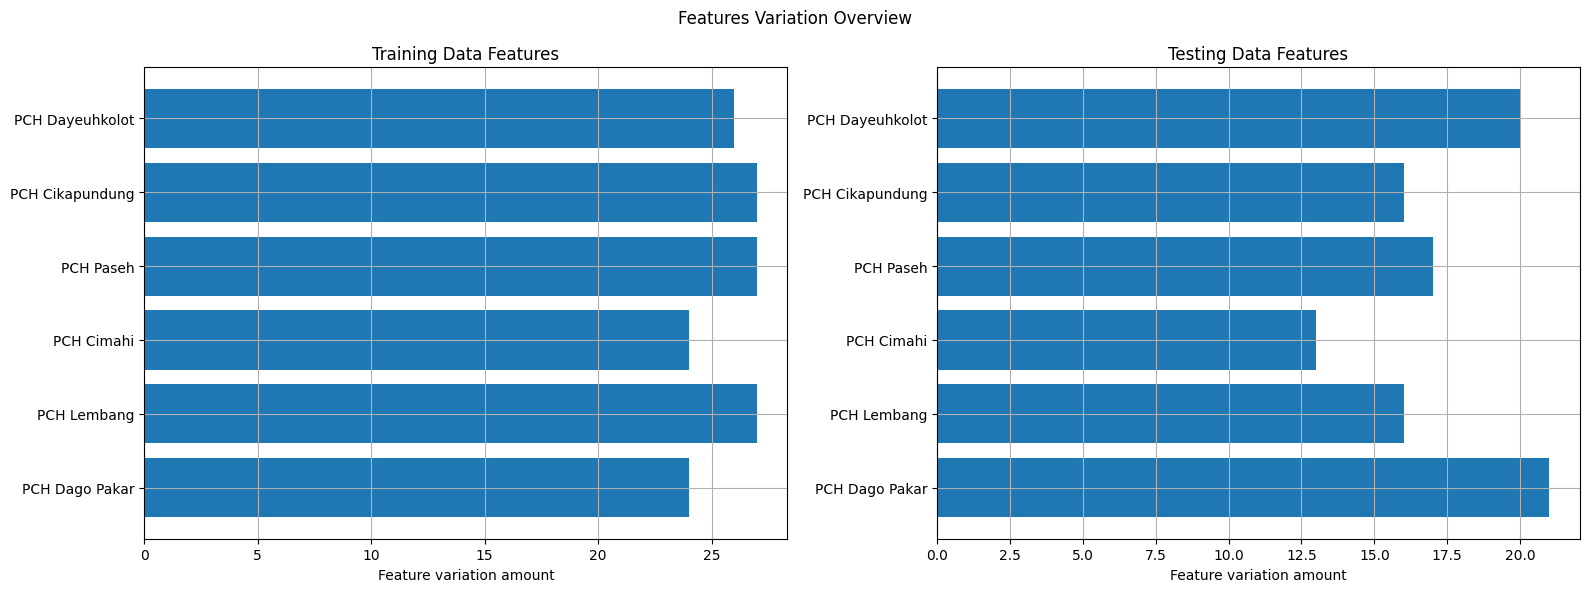

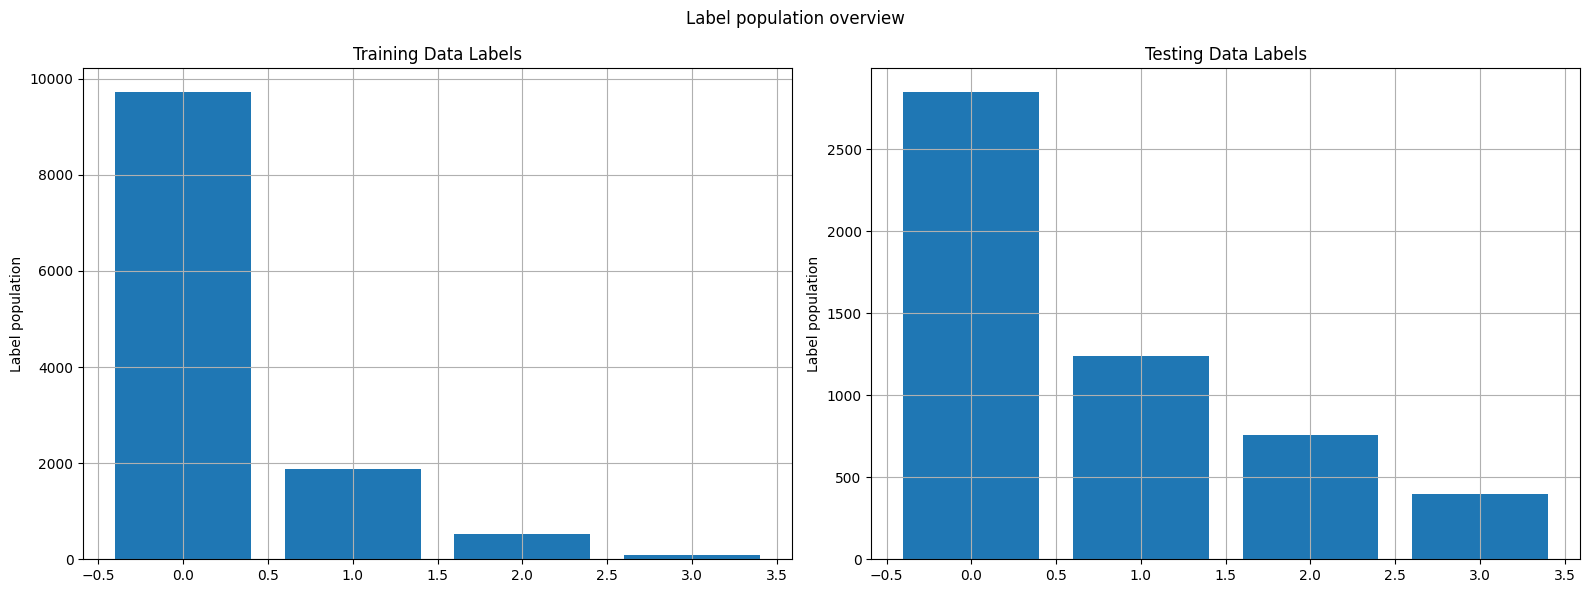

In [5]:
# Data overview
TRAIN_UNIQUE = []
TRAIN_OVERVIEW = [DF.iloc[:, :-1].columns.to_list(), []]
TEST_UNIQUE = []
TEST_OVERVIEW = [DF.iloc[:, :-1].columns.to_list(), []]
for i in range(TRAIN_FEATURES.shape[1]):
    TRAIN_UNIQUE.append(np.unique(TRAIN_FEATURES[:, i]))
    TRAIN_OVERVIEW[1].append(len(TRAIN_UNIQUE[i]))
    TEST_UNIQUE.append(np.unique(TEST_FEATURES[:, i]))
    TEST_OVERVIEW[1].append(len(TEST_UNIQUE[i]))

fig = plt.figure(figsize = (16, 6))
fig.suptitle("Features Variation Overview")
ax = fig.subplots(1, 2)

ax[0].barh(TRAIN_OVERVIEW[0], TRAIN_OVERVIEW[1])
ax[0].set_title("Training Data Features")
ax[0].set_xlabel("Feature variation amount")
ax[0].grid()

ax[1].barh(TEST_OVERVIEW[0], TEST_OVERVIEW[1])
ax[1].set_title("Testing Data Features")
ax[1].set_xlabel("Feature variation amount")
ax[1].grid()

plt.tight_layout()
plt.show()

TRAIN_POP = [[], []]
TRAIN_POP[0], TRAIN_POP[1] = np.unique(TRAIN_LABEL, return_counts = True)
TEST_POP = [[], []]
TEST_POP[0], TEST_POP[1] = np.unique(TEST_LABEL, return_counts = True)

fig = plt.figure(figsize = (16, 6))
fig.suptitle("Label population overview")
ax = fig.subplots(1, 2)

ax[0].bar(TRAIN_POP[0], TRAIN_POP[1])
ax[0].set_title("Training Data Labels")
ax[0].set_ylabel("Label population")
ax[0].grid()

ax[1].bar(TEST_POP[0], TEST_POP[1])
ax[1].set_title("Testing Data Labels")
ax[1].set_ylabel("Label population")
ax[1].grid()

plt.tight_layout()
plt.show()

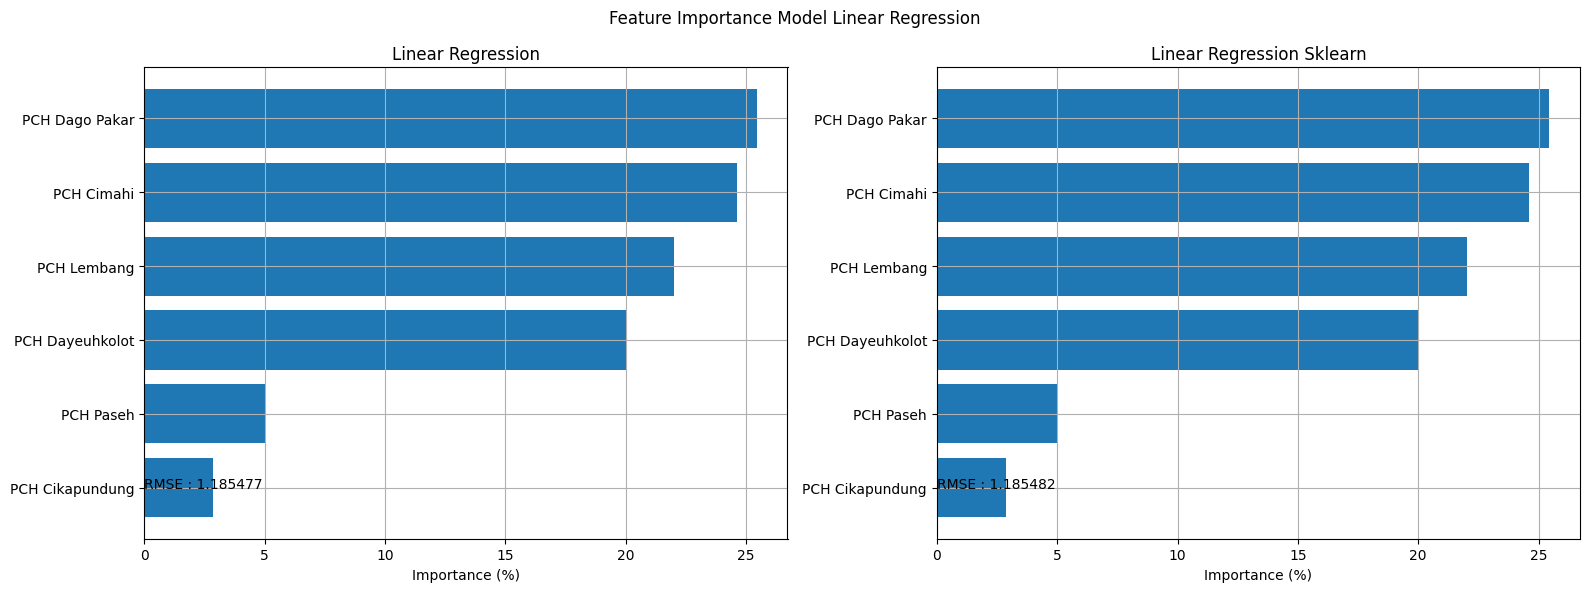

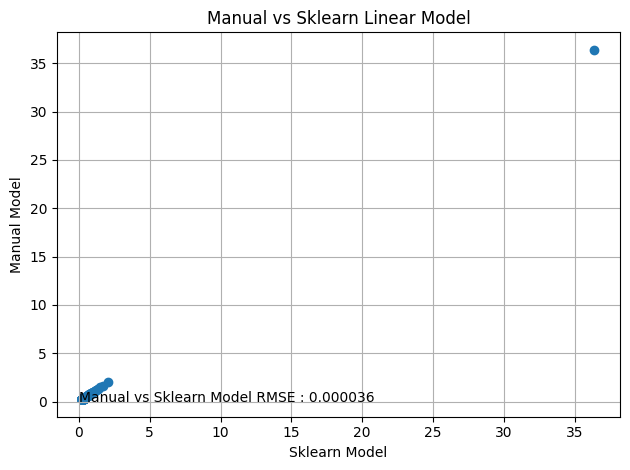

In [6]:
# Linear regression modelling
# model parameters: slope_calc (fit_intercept in sklearn) and force_nn (positive in sklearn)
LR_MODEL = linreg_fit(TRAIN_FEATURES, TRAIN_LABEL, force_nn = True)
LR_FEATURES = [DF.iloc[:, :-1].columns.to_list(), ((LR_MODEL[0]/LR_MODEL[0].sum())*100).tolist()]
LR_FEATURES = list_sort(LR_FEATURES)

# Sklearn model for comparison
LR_MODEL_SKLEARN = LinearRegression(positive = True)
LR_MODEL_SKLEARN.fit(TRAIN_FEATURES, TRAIN_LABEL)
LR_FEATURES_SKLEARN = [DF.iloc[:, :-1].columns.to_list(), ((LR_MODEL_SKLEARN.coef_/LR_MODEL_SKLEARN.coef_.sum())*100).tolist()]
LR_FEATURES_SKLEARN = list_sort(LR_FEATURES_SKLEARN)

# Plot linear regression model feature mmportances
fig = plt.figure(figsize = (16, 6))
fig.suptitle("Feature Importance Model Linear Regression")
ax = fig.subplots(1, 2)

ax[0].barh(LR_FEATURES[0], LR_FEATURES[1])
ax[0].text(0, 0, "RMSE : %f" % root_mean_squared_error(TEST_LABEL, linreg_model(TEST_FEATURES, LR_MODEL[0], LR_MODEL[1])))
ax[0].set_title("Linear Regression")
ax[0].set_xlabel("Importance (%)")
ax[0].grid()

ax[1].barh(LR_FEATURES_SKLEARN[0], LR_FEATURES_SKLEARN[1])
ax[1].text(0, 0, "RMSE : %f" % root_mean_squared_error(TEST_LABEL, LR_MODEL_SKLEARN.predict(TEST_FEATURES)))
ax[1].set_title("Linear Regression Sklearn")
ax[1].set_xlabel("Importance (%)")
ax[1].grid()

plt.tight_layout()
plt.show()

# Plot model comparison
plt.scatter(LR_MODEL_SKLEARN.predict(TEST_FEATURES), linreg_model(TEST_FEATURES, LR_MODEL[0], LR_MODEL[1]))
plt.text(0, 0, "Manual vs Sklearn Model RMSE : %f" % root_mean_squared_error(LR_MODEL_SKLEARN.predict(TEST_FEATURES), linreg_model(TEST_FEATURES, LR_MODEL[0], LR_MODEL[1])))
plt.title("Manual vs Sklearn Linear Model")
plt.xlabel("Sklearn Model")
plt.ylabel("Manual Model")
plt.grid()
plt.tight_layout()
plt.show()

Manual Model Accuracy :
          Actual 0  Actual 1  Actual 2  Actual 3
Result 0  0.540737  0.230300  0.140622  0.073078
Result 1  0.002480  0.004579  0.001908  0.001526
Result 2  0.000191  0.001145  0.001526  0.001336
Result 3  0.000572  0.000000  0.000000  0.000000
RMSE : 1.212178

Sklearn Model Accuracy :
          Actual 0  Actual 1  Actual 2  Actual 3
Result 0  0.540927  0.231063  0.140622  0.073459
Result 1  0.002290  0.004007  0.001908  0.001336
Result 2  0.000191  0.000954  0.001526  0.001145
Result 3  0.000572  0.000000  0.000000  0.000000
RMSE : 1.213358

          0.0      1.0       2.0       3.0
0.0  0.984736  0.00000  0.000000  0.000000
1.0  0.000954  0.00954  0.000000  0.000000
2.0  0.000382  0.00000  0.003816  0.000000
3.0  0.000000  0.00000  0.000000  0.000572
Manual vs Sklearn Model RMSE : 0.049804


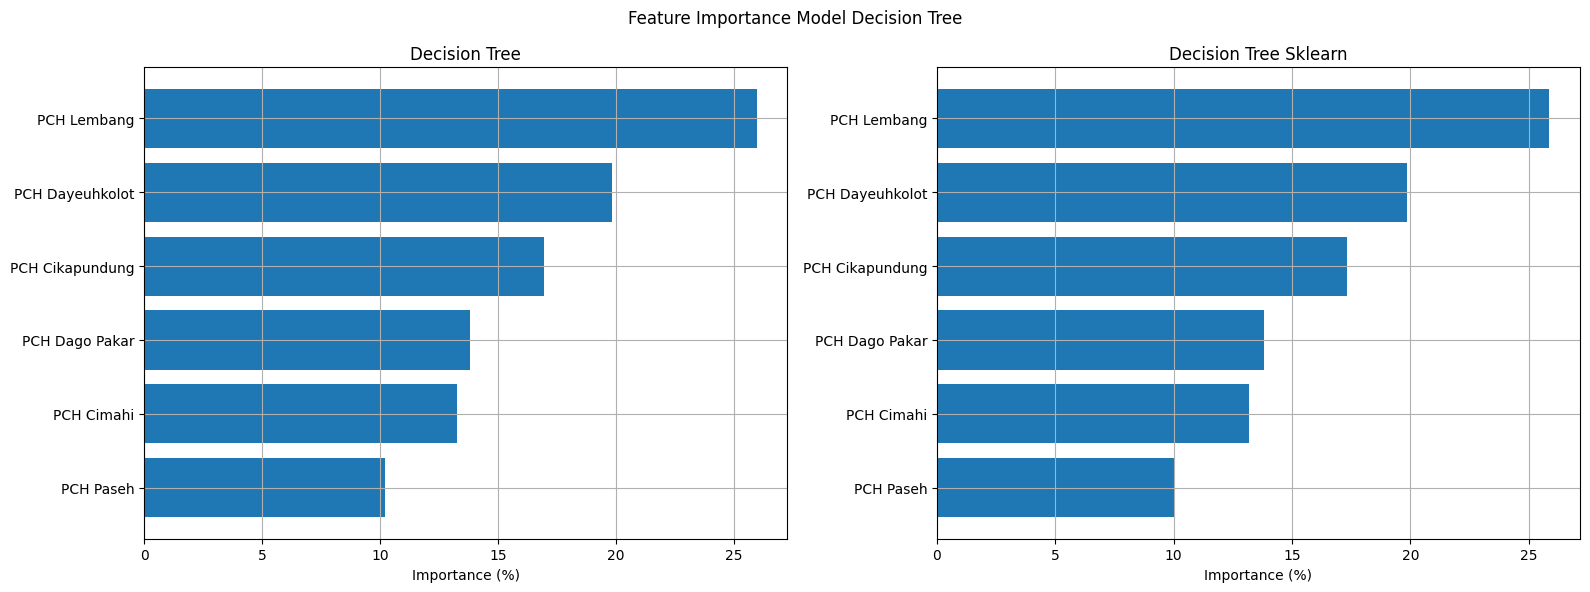

In [7]:
# Decision tree modelling
DT_MODEL = dtree_fit(TRAIN_FEATURES, TRAIN_LABEL, branch_limit = 12, min_samples = 8)
DT_FEATURES = [DF.iloc[:, :-1].columns.to_list(), ((DTREE_INFO['IMPORTANCES']/DTREE_INFO['IMPORTANCES'].sum())*100).tolist()]
DT_FEATURES = list_sort(DT_FEATURES)
RESULT_LABEL = dtree_model(TEST_FEATURES, DT_MODEL)
class_accuracy(RESULT_LABEL, TEST_LABEL, title = "Manual Model Accuracy :")

# Sklearn model for comparison
DT_MODEL_SKLEARN = DecisionTreeClassifier(max_depth = 12, min_samples_split = 8)
DT_MODEL_SKLEARN.fit(TRAIN_FEATURES, TRAIN_LABEL)
DT_FEATURES_SKLEARN = [DF.iloc[:, :-1].columns.to_list(), (DT_MODEL_SKLEARN.feature_importances_*100).tolist()]
DT_FEATURES_SKLEARN = list_sort(DT_FEATURES_SKLEARN)
RESULT_LABEL_SKLEARN = DT_MODEL_SKLEARN.predict(TEST_FEATURES)
class_accuracy(RESULT_LABEL_SKLEARN, TEST_LABEL, title = "Sklearn Model Accuracy :")

# Show model comparison
RESULT_LABEL = dtree_model(TEST_FEATURES, DT_MODEL)
RESULT_LABEL_SKLEARN = DT_MODEL_SKLEARN.predict(TEST_FEATURES)
COMPARISON_TABLE = np.zeros((len(np.unique(RESULT_LABEL)), len(np.unique(RESULT_LABEL_SKLEARN))))
for j in range(len(RESULT_LABEL)):
    COMPARISON_TABLE[int(RESULT_LABEL[j]), int(RESULT_LABEL_SKLEARN[j])] += 1

COMPARISON_TABLE = COMPARISON_TABLE/len(RESULT_LABEL)
COMPARISON_TABLE = pd.DataFrame(data = COMPARISON_TABLE, index = np.unique(RESULT_LABEL), columns = np.unique(RESULT_LABEL_SKLEARN))
print(COMPARISON_TABLE)
print("Manual vs Sklearn Model RMSE : %f" % root_mean_squared_error(DT_MODEL_SKLEARN.predict(TEST_FEATURES), dtree_model(TEST_FEATURES, DT_MODEL)))

# Plot decision tree model feature importances
fig = plt.figure(figsize = (16, 6))
fig.suptitle("Feature Importance Model Decision Tree")
ax = fig.subplots(1, 2)

ax[0].barh(DT_FEATURES[0], DT_FEATURES[1])
ax[0].set_title("Decision Tree")
ax[0].set_xlabel("Importance (%)")
ax[0].grid()

ax[1].barh(DT_FEATURES_SKLEARN[0], DT_FEATURES_SKLEARN[1])
ax[1].set_title("Decision Tree Sklearn")
ax[1].set_xlabel("Importance (%)")
ax[1].grid()

plt.tight_layout()
plt.show()

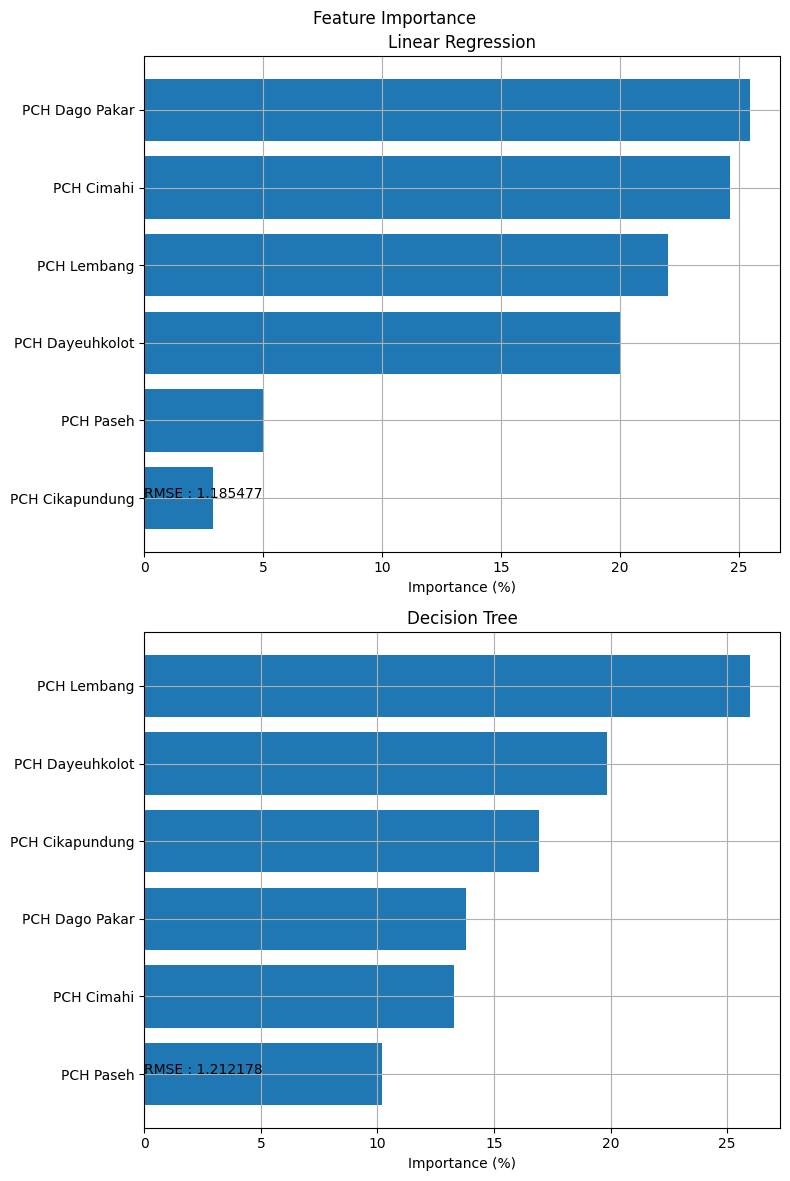

In [8]:
# Plot all feature importances
fig = plt.figure(figsize = (8, 12))
fig.suptitle("Feature Importance")
ax = fig.subplots(2, 1)

ax[0].barh(LR_FEATURES[0], LR_FEATURES[1])
ax[0].text(0, 0, "RMSE : %f" % root_mean_squared_error(TEST_LABEL, linreg_model(TEST_FEATURES, LR_MODEL[0], LR_MODEL[1])))
ax[0].set_title("Linear Regression")
ax[0].set_xlabel("Importance (%)")
ax[0].grid()

ax[1].barh(DT_FEATURES[0], DT_FEATURES[1])
ax[1].text(0, 0, "RMSE : %f" % root_mean_squared_error(TEST_LABEL, RESULT_LABEL))
ax[1].set_title("Decision Tree")
ax[1].set_xlabel("Importance (%)")
ax[1].grid()

plt.tight_layout()
plt.show()

In [9]:
# Show decision trees
pp.pprint(DT_MODEL)
print(export_text(DT_MODEL_SKLEARN))

{'1 <= 0.0': [{'5 <= 3.5': [{'0 <= 0.0': [{'3 <= 1.0': [{'3 <= 0.0': [{'2 <= 7.0': [{'4 <= 8.5': [{'2 <= 0.1': [{'5 <= 2.0': [{'4 <= 2.0': [{'4 <= 1.0': [[np.float64(0.0),
                                                                                                                                                           'reached_branch_limit'],
                                                                                                                                                          {'4 <= 1.5': [[np.float64(0.0),
                                                                                                                                                                         'reached_branch_limit'],
                                                                                                                                                                        [np.float64(0.0),
                                                                                  